# Best model

## 1. Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import warnings, sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
from colorama import Fore, Style


In [3]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

In [4]:
from hydrosense.params import *
from hydrosense.database.bigquery import load_pem_bq, info_piezo, load_plean
from hydrosense.preprocess.preprocessor import preprocess_week, preprocess_week_w_PU_synth, split_data, split_lagged_data, make_preproc_week
from hydrosense.preprocess.cleaning import clean_piezo

from hydrosense.utils.evap import estim_PU

from hydrosense.interface.main import evaluate, evaluate_deeper, preprocess, train
from hydrosense.ml_logic.folding import get_folds
from hydrosense.ml_logic import base


Verification de la location du fichier présent BigQuery:  /home/charourou/projects/Projet_Hydrosense/hydrosense/database/bigquery.py

Loading XGBoost...

✅ XGBoost loaded (0.0s)


In [5]:
FEATURE_COLS = ["semaine_sin","semaine_cos", "PU_synth", "PC1", "PC2", "PC3"]
FEATURE_COLS = ["semaine_sin","semaine_cos", "PU_synth"]
DATA_CODE_PIEZO = "BSS001QHYH"
df = load_plean(DATA_CODE_PIEZO)

TRAIN_END  = "2025-02-28"
TEST_START = "2025-03-01"
TEST_END   = "2025-05-31"

✅ BSS001QHYH : 11821 lignes de features ML chargées.


In [6]:
df.head()

,bss_id,date_mesure,niveau_nappe_eau,RR_synth,TM_synth,FFM_synth,PU_synth,PC1,PC2,PC3
0,BSS001QHYH,1994-01-18,14.20,0.0,-1.6,2.3,-0.761,5.529467,-0.907712,0.465264
1,BSS001QHYH,1994-01-19,14.20,0.0,-2.4,1.3,-0.520,5.507861,-0.903470,0.462943
2,BSS001QHYH,1994-01-20,14.13,1.4,1.6,1.6,0.677,5.480702,-0.894308,0.457180
3,BSS001QHYH,1994-01-21,14.07,0.8,3.5,1.4,0.070,5.442173,-0.881357,0.449040
4,BSS001QHYH,1994-01-22,14.00,0.0,5.7,0.5,-0.425,5.387199,-0.863381,0.437800


In [7]:
df_week = preprocess_week(df)

X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_week, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END )
X_train_df, y_train_df


⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1689 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1623 | Test : 13



(             PU_synth  semaine_sin  semaine_cos
 date_mesure                                    
 1994-01-23      0.484     0.354605     0.935016
 1994-01-30     -1.878     0.464723     0.885456
 1994-02-06     22.949     0.568065     0.822984
 1994-02-13     16.082     0.663123     0.748511
 1994-02-20      4.810     0.748511     0.663123
 ...               ...          ...          ...
 2025-01-26      3.733     0.464723     0.885456
 2025-02-02     21.363     0.568065     0.822984
 2025-02-09      5.558     0.663123     0.748511
 2025-02-16     -1.079     0.748511     0.663123
 2025-02-23     -0.364     0.822984     0.568065
 
 [1623 rows x 3 columns],
 date_mesure
 1994-01-23    14.090000
 1994-01-30    13.707143
 1994-02-06    13.662857
 1994-02-13    13.732857
 1994-02-20    13.657143
                 ...    
 2025-01-26    13.198571
 2025-02-02    13.342857
 2025-02-09    13.227143
 2025-02-16    13.088571
 2025-02-23    13.010000
 Freq: W-SUN, Name: niveau_nappe_eau, Length: 1

In [8]:
df_week.head()

,niveau_nappe_eau,RR_synth,PU_synth,TM_synth,PC1,PC2,PC3,FFM_synth,semaine_sin,semaine_cos
date_mesure,,,,,,,,,,
1994-01-23,14.090000,5.2,0.484,2.400000,5.437909,-0.878704,0.447234,1.766667,0.354605,0.935016
1994-01-30,13.707143,11.2,-1.878,7.842857,4.741158,-0.606062,0.271497,4.785714,0.464723,0.885456
1994-02-06,13.662857,33.6,22.949,6.485714,3.962465,-0.229476,0.021721,3.571429,0.568065,0.822984
1994-02-13,13.732857,27.4,16.082,5.885714,4.112225,-0.265872,0.043006,3.814286,0.663123,0.748511
1994-02-20,13.657143,17.2,4.810,5.885714,4.193190,-0.282091,0.051946,4.200000,0.748511,0.663123


## 2. Preprocess

In [9]:
# TRAIN / VAL Folding
# TODO for weekly folding
splits_ml = get_folds(X_train_df.index, n_splits=25, min_train_years=3 , val_months_duration= 3)

len(splits_ml)
len(splits_ml[0])
splits_ml[0]

print('Validation index span : ')
X_train_df.index[splits_ml[10][1]]

Validation index span : 


DatetimeIndex(['2011-03-06', '2011-03-13', '2011-03-20', '2011-03-27',
               '2011-04-03', '2011-04-10', '2011-04-17', '2011-04-24',
               '2011-05-01', '2011-05-08', '2011-05-15', '2011-05-22',
               '2011-05-29'],
              dtype='datetime64[us]', name='date_mesure', freq=None)

In [10]:
def cal_rmsse(y_true, y_pred, y_train_hist):
    # Erreur quadratique moyenne modèle
    numerator = np.mean((y_true - y_pred) ** 2)

    # Erreur quadratique moyenne de la persistance sur le train (Le bas)
    # np.diff(y_train_hist) fait la soustraction entre la semaine T et la semaine T-1
    denominator = np.mean(np.diff(y_train_hist) ** 2)
    return np.sqrt(numerator / denominator)

In [11]:
all_results = []  # Stocke les résultats pour chaque piezo

# temporary loop - - - -
for bss in TARGETS_BSS[10:11]:


    # _____________________________________________________________________________________________
    # OLD - Manual loop
    # _____________________________________________________________________________________________
    df = load_plean(bss)
    df_week = preprocess_week(df)
    X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_week,
                                                              FEATURE_COLS, TARGET_COL,
                                                              TRAIN_END, TEST_START, TEST_END
                                                              )

    base1, _  = train(X_train_df, y_train_df,
                    pick_model = 'BASE',
                    optimize = False
                    )
    # _____________________________________________________________________________________________


    Xt, Xe, yt, ye, scaler = make_preproc_week(df, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END)


    base, _ = train(Xt, yt, pick_model = 'BASE', optimize = False
                    )

    lasso, _ = train(Xt, yt, pick_model= 'LASSO' , optimize= False  )


✅ BSS001VAJT : 11994 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 838 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 791 | Test : 13

⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1712 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1646 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.



After splits and preproc -- a litte baseline sounds good

In [12]:
df_week

,niveau_nappe_eau,RR_synth,PU_synth,TM_synth,PC1,PC2,PC3,FFM_synth,semaine_sin,semaine_cos
date_mesure,,,,,,,,,,
2010-01-03,28.058571,38.11,29.432,7.271429,-2.367069,-0.921458,-1.046364,2.842857,0.120537,0.992709
2010-01-10,28.227143,7.32,0.292,-1.985714,-2.436849,-1.066147,-0.911389,4.457143,0.120537,0.992709
2010-01-17,28.448571,38.02,29.945,4.071429,-2.662786,-1.541981,-0.969805,2.985714,0.239316,0.970942
2010-01-24,28.774286,12.49,3.955,6.257143,-2.788534,-1.314283,-0.897103,2.528571,0.354605,0.935016
2010-01-31,29.011429,8.33,-0.212,2.157143,-2.567126,-1.673332,-1.029155,3.657143,0.464723,0.885456
...,...,...,...,...,...,...,...,...,...,...
2025-12-21,30.101429,19.87,12.009,10.384286,0.669464,-1.486025,-0.328112,2.042857,-0.120537,0.992709
2025-12-28,30.150000,0.20,-8.392,4.408571,1.353956,0.044222,-1.274877,3.685714,0.0,1.0
2026-01-04,30.162857,0.37,-5.629,-0.477143,1.489597,0.197658,-1.945572,2.900000,0.120537,0.992709


In [13]:
display(X_train_df.head())
display(Xt.columns)
display(Xt.describe())


if hasattr(lasso, 'coef_'):
    print(f"\n🧠 Poids des variables calculés par le Lasso : alpha {lasso.alpha}")

    for col, coef in zip(Xt.columns, lasso.coef_):
        print(f" ── {col:<18} : {coef:+.4f}")


,PU_synth,semaine_sin,semaine_cos
date_mesure,,,
2010-01-03,29.432,0.120537,0.992709
2010-01-10,0.292,0.120537,0.992709
2010-01-17,29.945,0.239316,0.970942
2010-01-24,3.955,0.354605,0.935016
2010-01-31,-0.212,0.464723,0.885456


Index(['semaine_sin', 'semaine_cos', 'niveau_nappe_eau_lag_1',
       'niveau_nappe_eau_lag_2', 'niveau_nappe_eau_lag_3',
       'niveau_nappe_eau_lag_4', 'niveau_nappe_eau_lag_52', 'PU_synth_lag_1',
       'PU_synth_lag_2', 'PU_synth_lag_3', 'PU_synth_lag_4'],
      dtype='object')

,semaine_sin,semaine_cos,niveau_nappe_eau_lag_1,niveau_nappe_eau_lag_2,niveau_nappe_eau_lag_3,niveau_nappe_eau_lag_4,niveau_nappe_eau_lag_52,PU_synth_lag_1,PU_synth_lag_2,PU_synth_lag_3,PU_synth_lag_4
count,1594.0,1594.0,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03,1.594000e+03
mean,-0.006399,0.010764,3.031174e-16,-6.597260e-16,-7.132173e-17,2.335787e-15,1.881111e-15,-1.448723e-17,-5.572010e-18,-2.228804e-18,-2.228804e-18
std,0.706301,0.708245,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00,1.000314e+00
min,-1.0,-1.0,-1.642259e+00,-1.642467e+00,-1.642568e+00,-1.642526e+00,-1.628425e+00,-1.671036e+00,-1.671098e+00,-1.669300e+00,-1.667703e+00
25%,-0.748511,-0.663123,-7.340184e-01,-7.339179e-01,-7.338737e-01,-7.338920e-01,-7.388758e-01,-7.179283e-01,-7.180174e-01,-7.180582e-01,-7.174863e-01
50%,-0.0,-0.0,-1.708832e-01,-1.705913e-01,-1.704573e-01,-1.705124e-01,-1.756499e-01,-1.773046e-01,-1.774092e-01,-1.770450e-01,-1.757213e-01
75%,0.663123,0.748511,4.809612e-01,4.814746e-01,4.817126e-01,4.816148e-01,4.693436e-01,4.724568e-01,4.723335e-01,4.723209e-01,4.715002e-01
max,1.0,1.0,3.717725e+00,3.719339e+00,3.720093e+00,3.719783e+00,3.718207e+00,4.376627e+00,4.376392e+00,4.375829e+00,4.378317e+00



🧠 Poids des variables calculés par le Lasso : alpha 0.01
 ── semaine_sin        : +0.0087
 ── semaine_cos        : +0.0000
 ── niveau_nappe_eau_lag_1 : +1.8757
 ── niveau_nappe_eau_lag_2 : +0.0000
 ── niveau_nappe_eau_lag_3 : -0.0000
 ── niveau_nappe_eau_lag_4 : -0.0000
 ── niveau_nappe_eau_lag_52 : +0.0000
 ── PU_synth_lag_1     : +0.0919
 ── PU_synth_lag_2     : +0.0556
 ── PU_synth_lag_3     : +0.0204
 ── PU_synth_lag_4     : +0.0180


In [14]:
# Trouver l'index de la colonne dans le scaler
nom_colonne = "niveau_nappe_eau_lag_1"
index_col = list(scaler.feature_names_in_).index(nom_colonne)

# Extraire la moyenne et l'écart-type spécifiques à cette colonne
moyenne_col = scaler.mean_[index_col]
ecart_type_col = scaler.scale_[index_col]

# Appliquer la formule mathématique de la standardisation (Z-score)
moyenne_col , ecart_type_col

(np.float64(29.22681439326044), np.float64(1.9083213394180198))

In [15]:
# A single PIEZO - TEST - on the basem
# - - - - - -
y_pred_baseline = base.predict(X_test_df)
print('erreur baseline.')
error1 = cal_rmsse(y_test_df.values, y_pred_baseline, y_train_df.values)

# Evaluate function from main should work here
error2 = cal_rmsse(ye.values, y_pred_baseline, yt.values)
print(error1, error2)

erreur baseline.
16.973913623742302 18.231254825513506


In [16]:
from hydrosense.interface.main import pred_future, pred

y_pred = pd.Series(lasso.predict(Xe), index = Xe.index)
# y_pred = pred(lasso, Xe)
y_pred, y_pred_baseline


y_pred2 = pred_future(lasso, Xt, scaler)

y_pred, y_pred2


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



(date_mesure
 2025-03-02    31.762486
 2025-03-09    31.702719
 2025-03-16    31.671281
 2025-03-23    31.552902
 2025-03-30    31.387749
 2025-04-06    31.160857
 2025-04-13    31.109149
 2025-04-20    30.904089
 2025-04-27    31.116673
 2025-05-04    31.017218
 2025-05-11    30.940453
 2025-05-18    30.871595
 2025-05-25    30.715720
 dtype: float64,
 2025-03-02    31.674
 2025-03-09    31.598
 2025-03-16    31.432
 2025-03-23    31.239
 2025-03-30    31.028
 2025-04-06    30.821
 2025-04-13    30.617
 2025-04-20    30.417
 2025-04-27    30.220
 2025-05-04    30.025
 2025-05-11    29.834
 2025-05-18    29.645
 2025-05-25    29.458
 Name: niveau_nappe_eau, dtype: float64)

In [ ]:
def comparaison_rapide():
    # Graphique de comparaison
    plt.figure(figsize=(12, 5))
    plt.plot(yt.tail(52), label='Train (Historique)', color='blue')
    plt.plot(ye, label='Test (Réalité)', color='green', marker='o')
    plt.plot(y_pred_baseline, label='Baseline', color='magenta', linestyle='-', marker='o')
    plt.plot(y_pred_lasso, label= 'Lasso neutre',  color='red', linestyle='--', marker='x')
    plt.plot(y_pred_xgb, label='Lasso sec', color='black', linestyle='--', marker='x')

    plt.title("Prévisions avec Lasso")
    plt.xlabel("Date")
    plt.ylabel("Niveau de la nappe")
    plt.legend()
    plt.grid(True)
    plt.show()

### 3.5 Validation on folding

In [ ]:
# df = load_plean(bss)
# Xt, Xe, yt, ye, scaler = make_preproc_week(df, FEATURE_COLS, TARGET_COL,




# for s in splits_ml:
#     print(s[0][-1],
#     X_train_df.index[s[0][-1]])

370 2017-02-05 00:00:00
422 2018-02-04 00:00:00
483 2019-04-07 00:00:00
531 2020-03-08 00:00:00
583 2021-03-07 00:00:00
635 2022-03-06 00:00:00
683 2023-02-05 00:00:00
735 2024-02-04 00:00:00


IndexError: index 801 is out of bounds for axis 0 with size 791

## 4. Comparaison sur boucle de Piezos

Production des résultats sur toutes les zones tests


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002DEZW
═══════════════════════════════════════════════════════
✅ BSS002DEZW : 10370 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1482 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1416 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1364 rows in 0.14s
   Train MAE  : 0.016
   Train RMSE : 0.0234
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



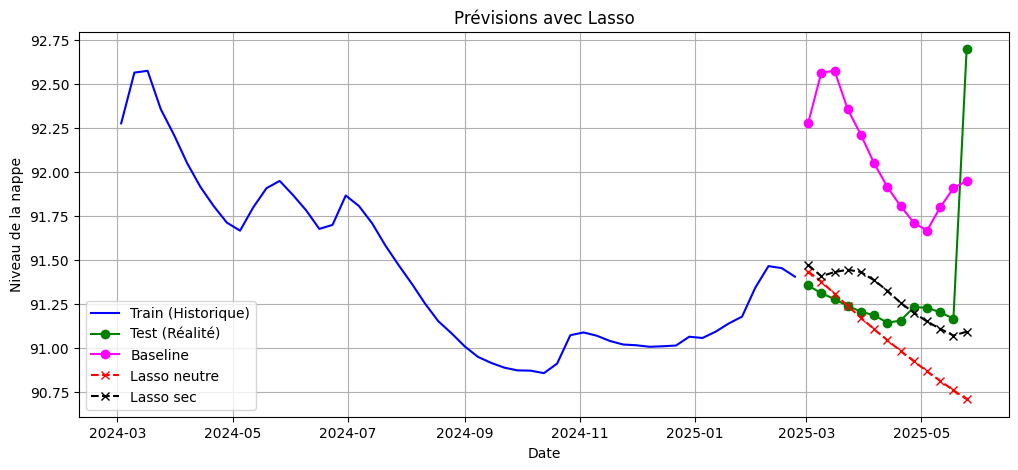


═══════════════════════════════════════════════════════
🔄 Traitement : BSS000ZPHJ
═══════════════════════════════════════════════════════
✅ BSS000ZPHJ : 7464 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1067 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1001 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 949 rows in 0.26s
   Train MAE  : 0.0197
   Train RMSE : 0.0275
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



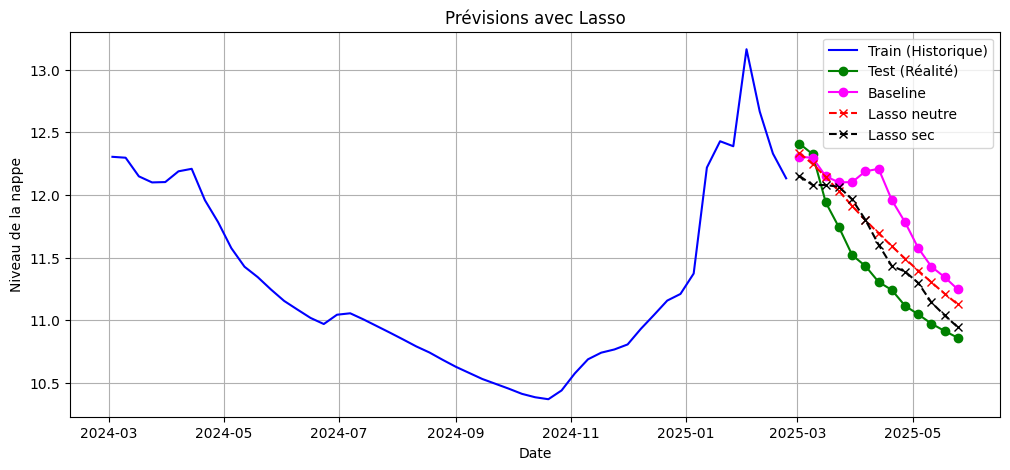


═══════════════════════════════════════════════════════
🔄 Traitement : BSS000ZQXN
═══════════════════════════════════════════════════════
✅ BSS000ZQXN : 6534 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 934 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 868 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 816 rows in 0.2s
   Train MAE  : 0.044
   Train RMSE : 0.0604
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



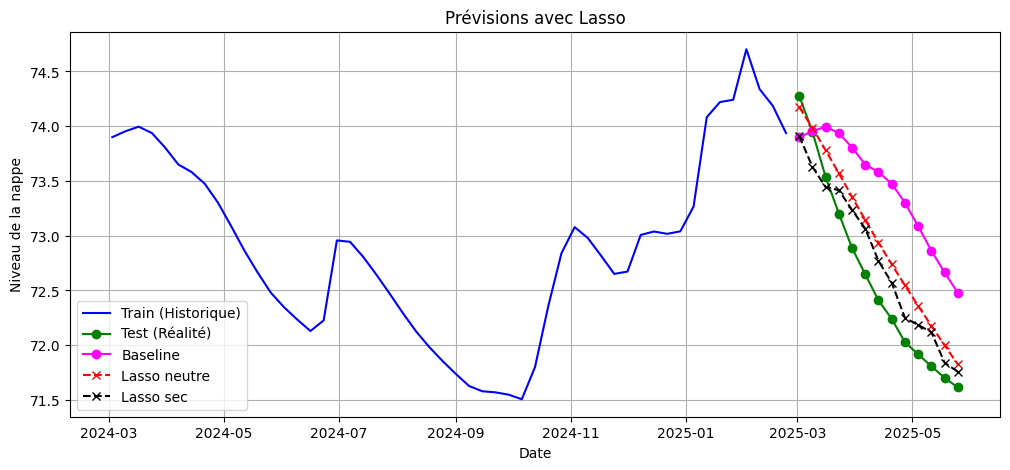


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001PGUQ
═══════════════════════════════════════════════════════
✅ BSS001PGUQ : 5221 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 746 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 680 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 628 rows in 0.17s
   Train MAE  : 0.0498
   Train RMSE : 0.0679
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



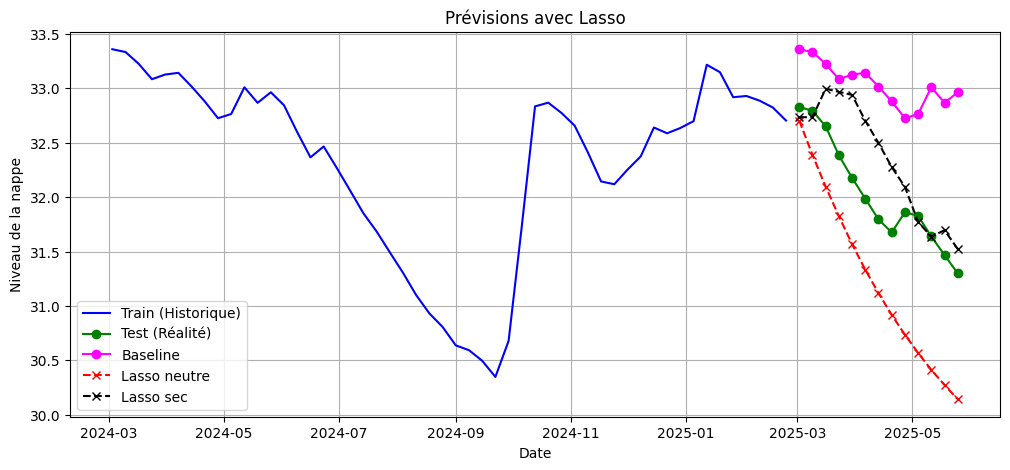


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001QTKG
═══════════════════════════════════════════════════════
✅ BSS001QTKG : 8852 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1265 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1199 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1147 rows in 0.26s
   Train MAE  : 0.1776
   Train RMSE : 0.2481
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



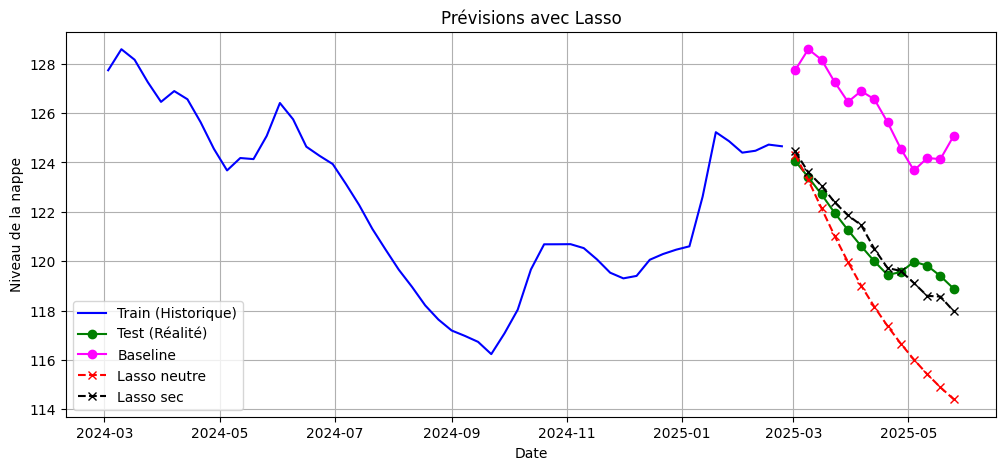


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001QSMT
═══════════════════════════════════════════════════════
✅ BSS001QSMT : 8713 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1243 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1177 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1125 rows in 1.13s
   Train MAE  : 0.052
   Train RMSE : 0.07
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



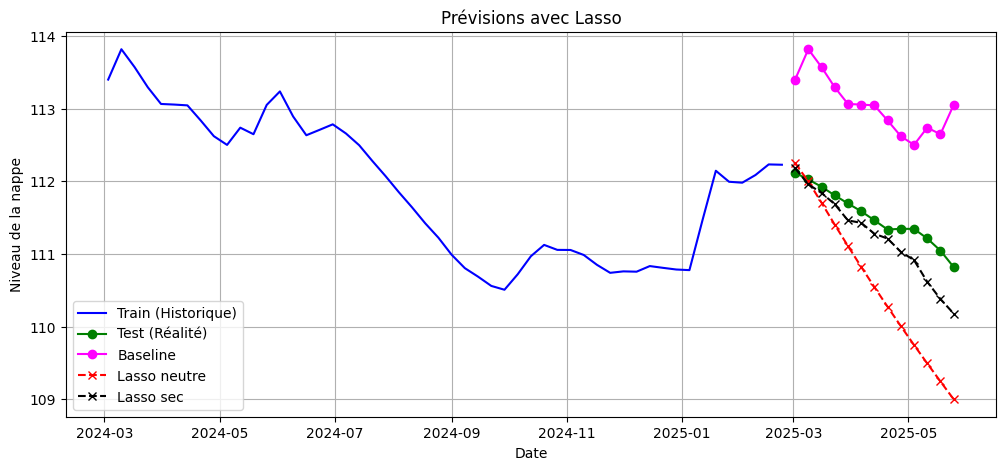


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001QHYH
═══════════════════════════════════════════════════════
✅ BSS001QHYH : 11821 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1689 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1623 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1571 rows in 0.57s
   Train MAE  : 0.092
   Train RMSE : 0.1253
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



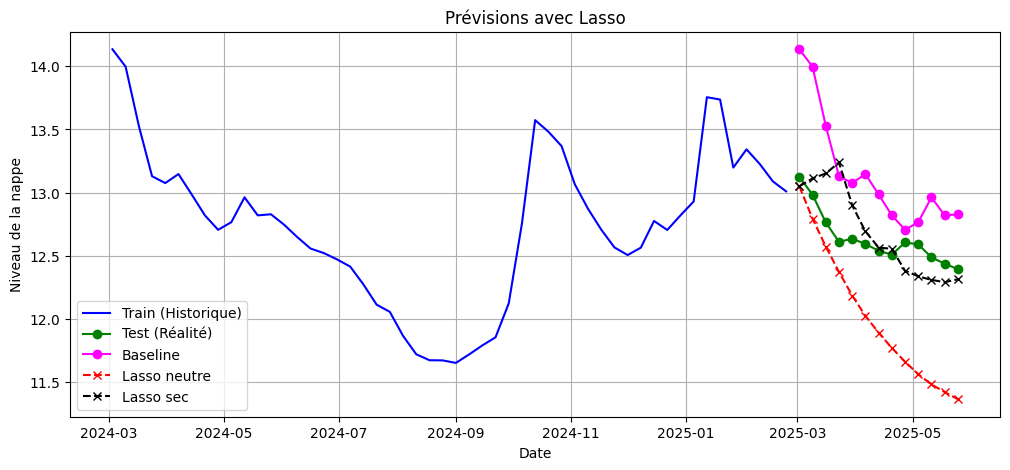


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001QHPU
═══════════════════════════════════════════════════════
✅ BSS001QHPU : 12072 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1725 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1659 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1607 rows in 0.17s
   Train MAE  : 0.0889
   Train RMSE : 0.1245
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



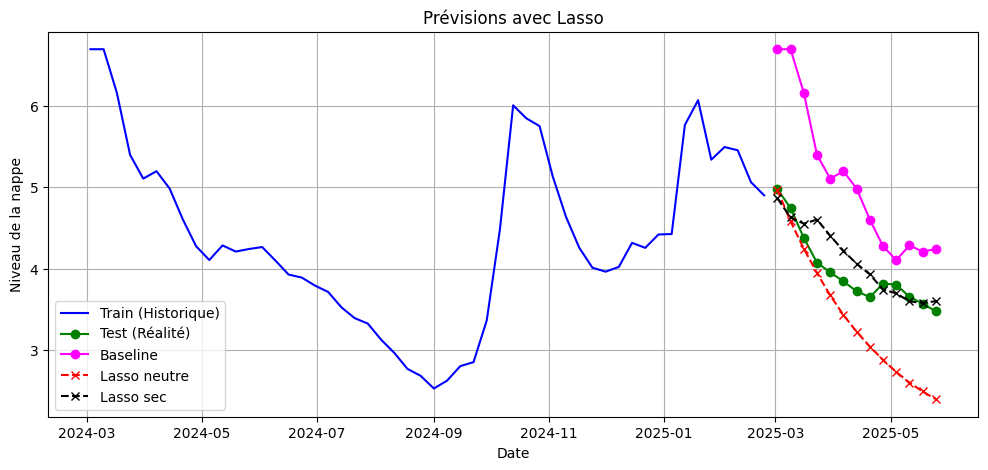


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001RQQE
═══════════════════════════════════════════════════════
✅ BSS001RQQE : 8738 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1243 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1177 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1125 rows in 0.15s
   Train MAE  : 0.0919
   Train RMSE : 0.1316
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



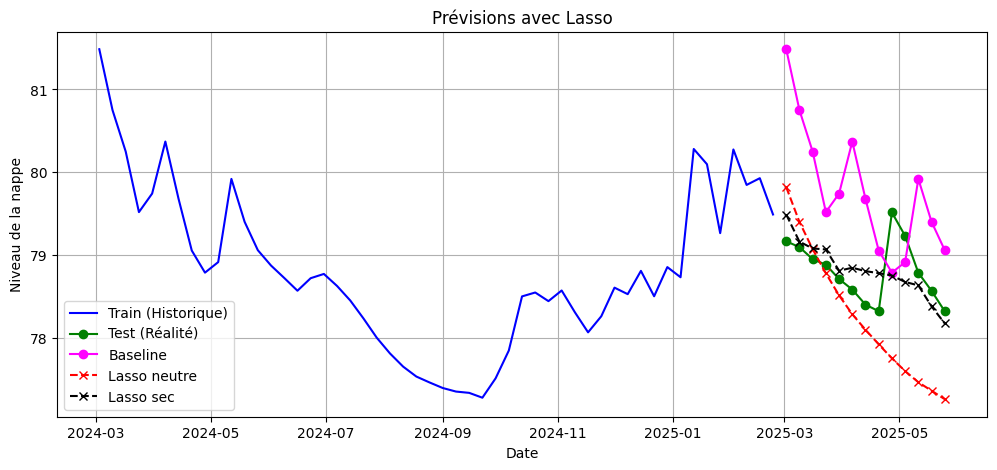


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001SHNE
═══════════════════════════════════════════════════════
✅ BSS001SHNE : 8888 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1270 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1204 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1152 rows in 0.2s
   Train MAE  : 0.1055
   Train RMSE : 0.1604
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



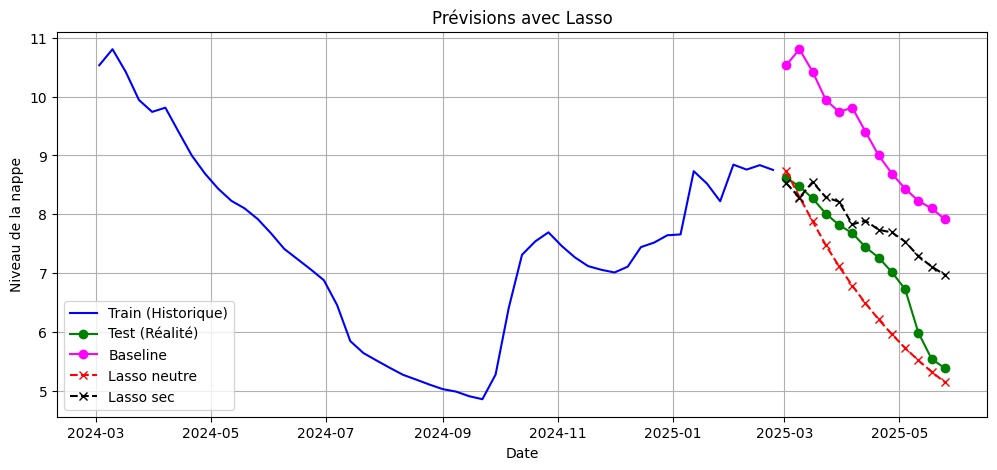


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001VAJT
═══════════════════════════════════════════════════════
✅ BSS001VAJT : 11994 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1712 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1646 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1594 rows in 0.32s
   Train MAE  : 0.0447
   Train RMSE : 0.061
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



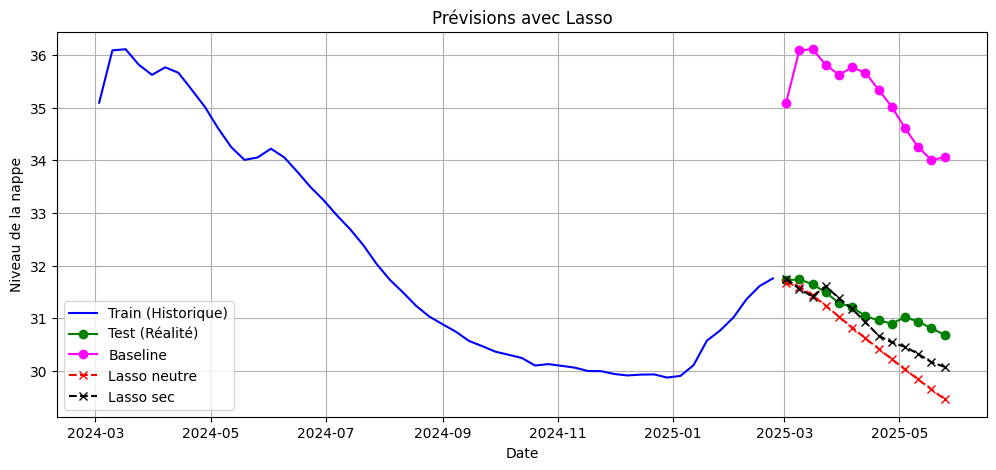


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001UCZQ
═══════════════════════════════════════════════════════
✅ BSS001UCZQ : 10089 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1441 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1375 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1323 rows in 0.15s
   Train MAE  : 0.3097
   Train RMSE : 0.4485
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



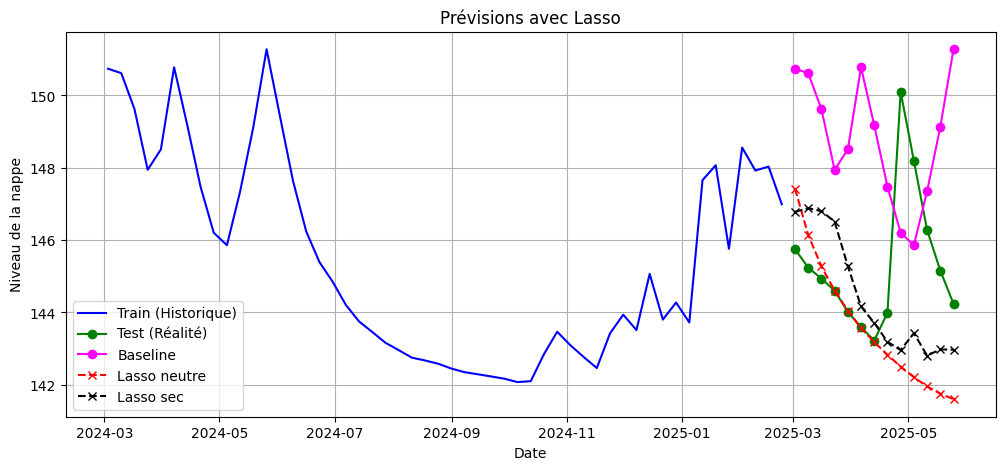


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001XBKZ
═══════════════════════════════════════════════════════
✅ BSS001XBKZ : 6913 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 988 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 922 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 870 rows in 0.2s
   Train MAE  : 0.0586
   Train RMSE : 0.0781
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



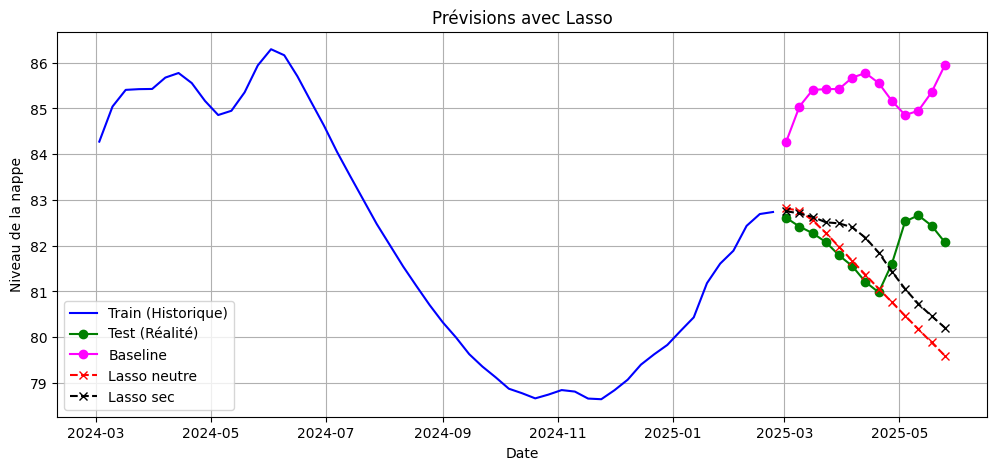


═══════════════════════════════════════════════════════
🔄 Traitement : BSS001WVPW
═══════════════════════════════════════════════════════
✅ BSS001WVPW : 6911 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 988 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 922 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 870 rows in 0.15s
   Train MAE  : 0.0227
   Train RMSE : 0.0302
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



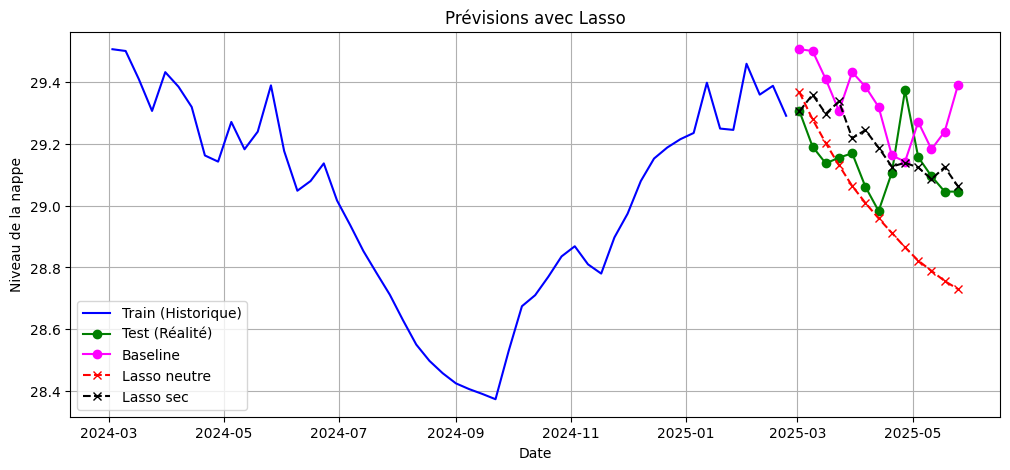


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002AFGV
═══════════════════════════════════════════════════════
✅ BSS002AFGV : 6582 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 941 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 875 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 823 rows in 0.15s
   Train MAE  : 0.0345
   Train RMSE : 0.0492
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



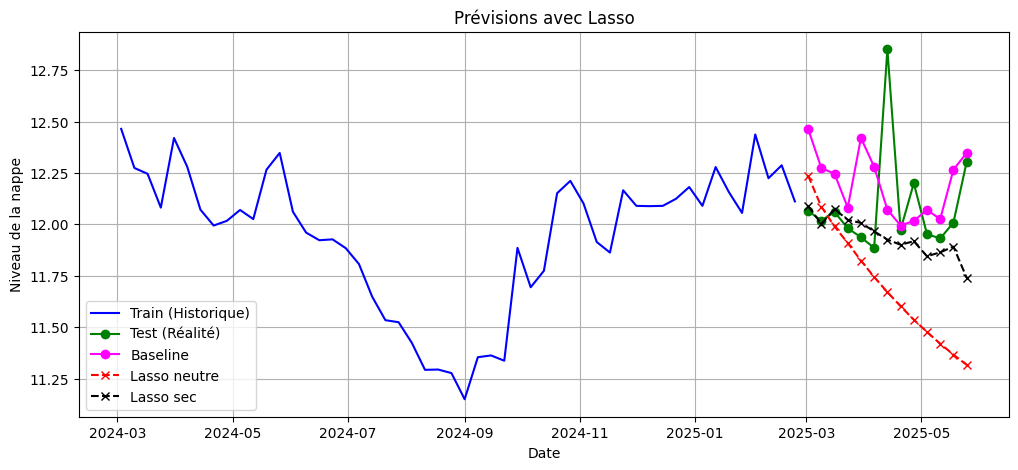


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002AXYY
═══════════════════════════════════════════════════════
✅ BSS002AXYY : 7274 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1026 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 960 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 908 rows in 0.2s
   Train MAE  : 0.0273
   Train RMSE : 0.0382
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



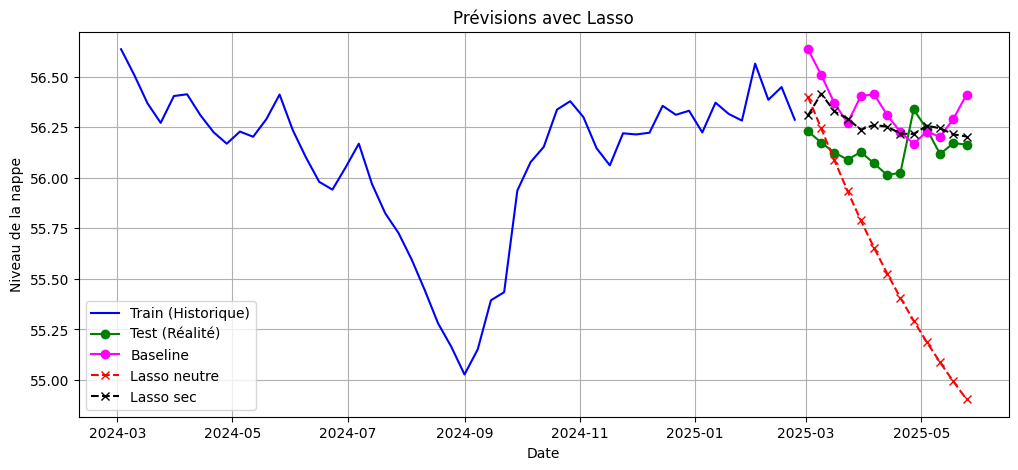


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002CAAM
═══════════════════════════════════════════════════════
✅ BSS002CAAM : 6738 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 649 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 583 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 531 rows in 0.16s
   Train MAE  : 0.0103
   Train RMSE : 0.0135
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



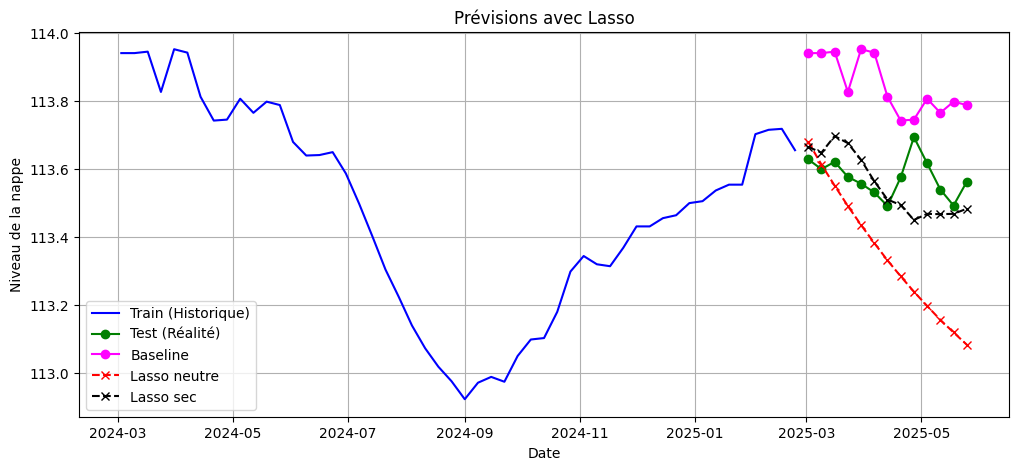


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002BGAF
═══════════════════════════════════════════════════════
✅ BSS002BGAF : 6528 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 549 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 483 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 431 rows in 0.19s
   Train MAE  : 0.0052
   Train RMSE : 0.0073
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



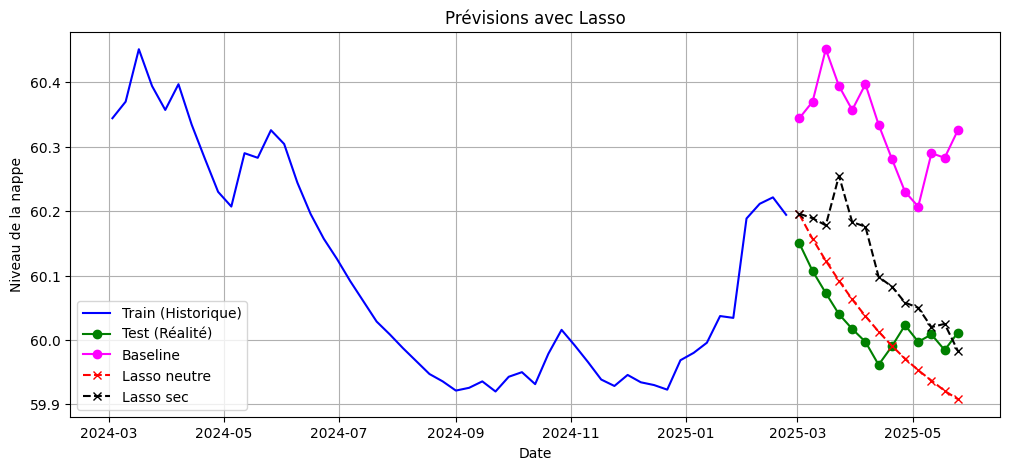


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002EDYK
═══════════════════════════════════════════════════════
✅ BSS002EDYK : 12261 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ Moyenne hebdomadaire — 1753 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1688 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 9 en Standard, 0 en MinMax.
⏳ Initialisation de la persistance annuelle (J-365)...
✅ train() done — Baseline prête.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


Use case: train

⭐️ Use case: train (Mode XGB)
Model initialized

Training model...
✅ Model trained on 1636 rows in 0.13s
   Train MAE  : 0.0534
   Train RMSE : 0.0753
✅ train() done 


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites


⭐️ Use case: pred_future

✅ pred_future() done — 13 semaines prédites



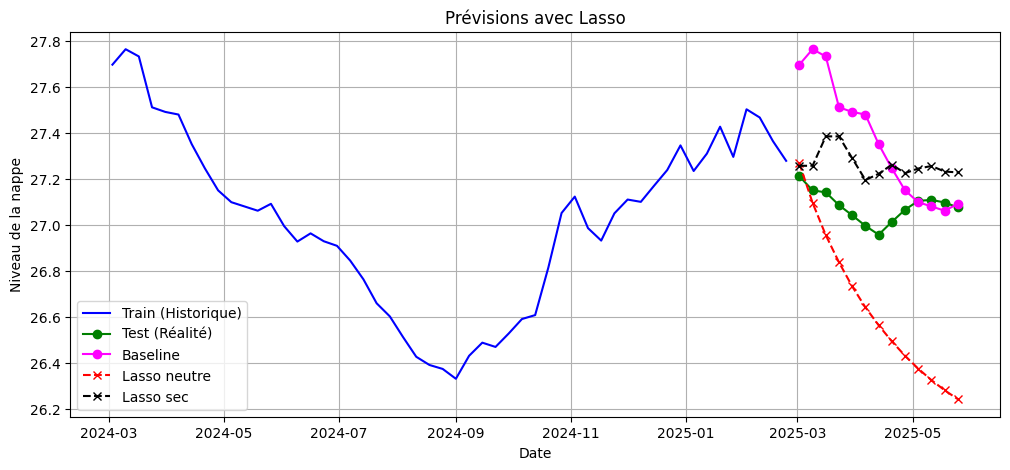

In [23]:
for bss in TARGETS_BSS:

    print(f"\n{'═'*55}")
    print(f"🔄 Traitement : {bss}")
    print(f"{'═'*55}")

    df = load_plean(bss)
    Xt, Xe, yt, ye, scaler = make_preproc_week(df, FEATURE_COLS, TARGET_COL, TRAIN_END, TEST_START, TEST_END)
    base, _ = train(Xt, yt, pick_model = 'BASE', optimize = False)
    lasso, _ = train(Xt, yt, pick_model= 'LASSO' , optimize= False  )
    xgb, _  = train(Xt, yt, pick_model= 'XGB' , optimize= False  )

    y_pred_baseline = base.predict(Xe)
    # y_pred = pred_future(lasso, Xt, scaler, scenario= 'sec')
    y_pred_lasso = pred_future(lasso, Xt, scaler, scenario= 'sec')
    y_pred_xgb = pred_future(xgb, Xt, scaler, scenario= 'saison')

    def comparaison_rapide():
    # Graphique de comparaison
        plt.figure(figsize=(12, 5))
        plt.plot(yt.tail(52), label='Train (Historique)', color='blue')
        plt.plot(ye, label='Test (Réalité)', color='green', marker='o')
        plt.plot(y_pred_baseline, label='Baseline', color='magenta', linestyle='-', marker='o')
        plt.plot(y_pred_lasso, label= 'Lasso neutre',  color='red', linestyle='--', marker='x')
        plt.plot(y_pred_xgb, label='Lasso sec', color='black', linestyle='--', marker='x')

        plt.title("Prévisions avec Lasso")
        plt.xlabel("Date")
        plt.ylabel("Niveau de la nappe")
        plt.legend()
        plt.grid(True)
        plt.show()

    # figure rapide
    comparaison_rapide()


## VIEUX CODE

In [ ]:

    try:
        # ── Chargement & preprocessing ───────────────────────────
        df = load_plean(bss)
        df_week = preprocess_week_w_PU_synth(df)
        X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_week)

        print(f"   Train : {len(X_train_df)} sem. | Test : {len(X_test_df)} sem.")

        # ── Baseline A : Persistance immédiate ───────────────────
        valeur_derniere = y_train_df.iloc[-1]
        y_pred_baseline_hebdo = np.full(len(y_test_df), fill_value=valeur_derniere)

        # ── Baseline B : Persistance saisonnière (J-52) ──────────
        y_pred_baseline_saisonniere = []
        for date in y_test_df.index:
            date_an_dernier = date - pd.Timedelta(weeks=52)
            idx = y_train_df.index.get_indexer([date_an_dernier], method='nearest')[0]
            y_pred_baseline_saisonniere.append(y_train_df.iloc[idx])
        y_pred_baseline_saisonniere = np.array(y_pred_baseline_saisonniere)

        # ── SARIMAX ───────────────────────────────────────────────
        try:
            model_sarimax = SARIMAX(
                y_train_df,
                order=(1, 0, 1),
                seasonal_order=(1, 0, 0, 52),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            preds_sarimax = model_sarimax.fit(disp=False).predict(
                start=len(y_train_df),
                end=len(y_train_df) + len(y_test_df) - 1
            ).values
        except Exception as e:
            print(f"   ⚠️ SARIMAX échoué ({e}) — remplacé par NaN")
            preds_sarimax = np.full(len(y_test_df), np.nan)

        # ── XGBoost best params ───────────────────────────────────
        best_xgb = XGBRegressor(
            colsample_bytree=0.6, learning_rate=0.1, max_depth=2,
            min_child_weight=5, n_estimators=500, subsample=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )
        best_xgb.fit(X_train_df, y_train_df)

        # ── Dictionnaire des modèles ──────────────────────────────
        models = {
            'Baseline (Semaine Dernière)': y_pred_baseline_hebdo,
            'Baseline (Année Dernière)':   y_pred_baseline_saisonniere,
            'SARIMAX(1,0,1)(1,0,0)[52]':   preds_sarimax,
            'Lasso':                        Lasso(alpha=0.01, random_state=42),
            'ElasticNet':                   ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
            'Random Forest':                RandomForestRegressor(n_estimators=300, max_depth=5,random_state=42, n_jobs=-1),
            'XGBoost Optimisé':             best_xgb,
        }

        # ── Calcul des métriques ──────────────────────────────────
        for name, m in models.items():
            if isinstance(m, np.ndarray):
                preds = m
            else:
                if name != 'XGBoost Optimisé':
                    m.fit(X_train_df, y_train_df)
                preds = m.predict(X_test_df)

            if np.any(np.isnan(preds)):
                mae, rmsse = np.nan, np.nan
            else:
                mae   = mean_absolute_error(y_test_df, preds)
                rmsse = cal_rmsse(y_test_df, preds, y_train_df)

            all_results.append({
                'BSS':         bss,
                'Modèle':      name,
                'MAE (m NGF)': round(mae, 4) if not np.isnan(mae) else np.nan,
                'RMSSE':       round(rmsse, 4) if not np.isnan(rmsse) else np.nan,
                'n_test':      len(y_test_df),
            })

        print(f"   ✅ OK")

    except Exception as e:
        print(f"   ❌ Erreur sur {bss} : {e}")
        continue

# ── Tableau global ────────────────────────────────────────────────────────────
df_all = pd.DataFrame(all_results)

# Vue synthétique : MAE moyenne par modèle sur tous les piézos
df_summary = (
    df_all.groupby('Modèle')[['MAE (m NGF)', 'RMSSE']]
    .mean()
    .round(4)
    .sort_values('MAE (m NGF)')
)

print("\n\n🏆 SYNTHÈSE TOUS PIÉZOS — MAE & RMSSE moyens")
print("═" * 55)
display(df_summary.style.background_gradient(cmap='RdYlGn_r'))

# Vue détaillée : tous les piézos × tous les modèles
df_pivot = df_all.pivot(index='BSS', columns='Modèle', values='MAE (m NGF)').round(4)
print("\n📊 MAE DÉTAILLÉE PAR PIÉZO ET MODÈLE")
display(df_pivot.style.background_gradient(cmap='RdYlGn_r', axis=1))

In [ ]:



Xtot = pd.concat([Xt, Xe])
ytot = pd.concat([yt, ye])


model, _ = train(Xtot, ytot, optimize=False)

forecast = pred_future(model, Xtot, n_weeks=13)

print(forecast)

✅ BSS001QHYH : 11821 lignes de features ML chargées.

⭐️ Use case: preprocess
✅ preprocess() done — 1689 semaines | 10 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 1623 | Test : 13

Adimensionnement des features (Standardisation)...
✅ Adimensionnement terminé : 12 en Standard, 0 en MinMax.

Use case: train (Mode Baseline Lasso)
✅ train() done — Modèle Lasso entraîné.


⭐️ Use case: pred_future
✅ Predicted 1 values


KeyError: 'niveau_nappe_eau'

In [ ]:
TRAINING_FEATURES = [
    'semaine_sin', 'semaine_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52',
    'PC1_lag_1', 'PC2_lag_1', 'PC3_lag_1',
    'PU_synth_lag_1', 'PU_synth_lag_2', 'PU_synth_lag_3', 'PU_synth_lag_4'
]


def predict_recursive(model, df_week: pd.DataFrame, n_weeks: int) -> np.ndarray:

    pu_seasonal = (
        df_week.groupby(df_week.index.isocalendar().week.astype(int))['PU_synth_lag_1']
        .mean().to_dict()
    )

    df_future = df_week.loc[:params.TEST_START_DATE].copy()
    predictions = []

    for i in range(n_weeks):
        last_row  = df_future[TRAINING_FEATURES].tail(1).values
        y_next    = float(model.predict(last_row)[0])
        next_date = df_future.index[-1] + pd.Timedelta(weeks=1)

        next_semaine = int(next_date.isocalendar().week)
        pu_future    = pu_seasonal.get(next_semaine, df_week['PU_synth_lag_1'].mean())

        new_row = pd.DataFrame({
            "niveau_nappe_eau": [y_next],
            "semaine_sin":      [np.sin(2 * np.pi * next_semaine / 52)],
            "semaine_cos":      [np.cos(2 * np.pi * next_semaine / 52)],
            # lags niveau — décalage en cascade
            "lag_1":            [y_next],
            "lag_2":            [df_future["lag_1"].iloc[-1]],
            "lag_3":            [df_future["lag_2"].iloc[-1]],
            "lag_4":            [df_future["lag_3"].iloc[-1]],
            "lag_52":           [df_future["niveau_nappe_eau"].iloc[-51]],
            # PC : on reporte les dernières valeurs connues
            "PC1_lag_1":        [df_future["PC1_lag_1"].iloc[-1]],
            "PC2_lag_1":        [df_future["PC2_lag_1"].iloc[-1]],
            "PC3_lag_1":        [df_future["PC3_lag_1"].iloc[-1]],
            # PU_synth : proxy saisonnier + décalage en cascade
            "PU_synth_lag_1":   [pu_future],
            "PU_synth_lag_2":   [df_future["PU_synth_lag_1"].iloc[-1]],
            "PU_synth_lag_3":   [df_future["PU_synth_lag_2"].iloc[-1]],
            "PU_synth_lag_4":   [df_future["PU_synth_lag_3"].iloc[-1]],
        }, index=[next_date])

        df_future = pd.concat([df_future, new_row])
        predictions.append(y_next)

    return np.array(predictions)

In [ ]:
all_results = []

for bss in params.TARGETS_BSS:
    print(f"\n{'═'*55}")
    print(f"🔄 Traitement : {bss}")
    print(f"{'═'*55}")

    try:
        # ── Chargement & preprocessing ───────────────────────────
        df      = load_plean(bss)
        df_week = preprocess_week_w_PU_synth(df)
        X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_week)

        print(f"   Train : {len(X_train_df)} sem. | Test : {len(X_test_df)} sem.")

        n_test = len(y_test_df)

        # ── Baseline A : Persistance immédiate ───────────────────
        y_pred_baseline_hebdo = np.full(n_test, fill_value=y_train_df.iloc[-1])

        # ── Baseline B : Persistance saisonnière (J-52) ──────────
        y_pred_baseline_saisonniere = []
        for date in y_test_df.index:
            date_an_dernier = date - pd.Timedelta(weeks=52)
            idx = y_train_df.index.get_indexer([date_an_dernier], method='nearest')[0]
            y_pred_baseline_saisonniere.append(y_train_df.iloc[idx])
        y_pred_baseline_saisonniere = np.array(y_pred_baseline_saisonniere)

        # ── SARIMAX — autorégressif par nature ───────────────────
        try:
            model_sarimax = SARIMAX(
                y_train_df,
                order=(1, 0, 1),
                seasonal_order=(1, 0, 0, 52),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            preds_sarimax = model_sarimax.fit(disp=False).predict(
                start=len(y_train_df),
                end=len(y_train_df) + n_test - 1
            ).values
        except Exception as e:
            print(f"   ⚠️ SARIMAX échoué ({e}) — remplacé par NaN")
            preds_sarimax = np.full(n_test, np.nan)

        # ── XGBoost — fit sur train uniquement ───────────────────
        best_xgb = XGBRegressor(
            colsample_bytree=0.6, learning_rate=0.1, max_depth=2,
            min_child_weight=5, n_estimators=500, subsample=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )
        best_xgb.fit(X_train_df, y_train_df)

        # ── Dictionnaire des modèles ──────────────────────────────
        models = {
            'Baseline (Semaine Dernière)': y_pred_baseline_hebdo,          # np.ndarray
            'Baseline (Année Dernière)':   y_pred_baseline_saisonniere,    # np.ndarray
            'SARIMAX(1,0,1)(1,0,0)[52]':   preds_sarimax,                  # np.ndarray
            'Lasso':                        Lasso(alpha=0.01, random_state=42),
            'ElasticNet':                   ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
            'Random Forest':                RandomForestRegressor(n_estimators=300, max_depth=5,
                                                random_state=42, n_jobs=-1),
            'XGBoost Optimisé':             best_xgb,
        }

        # ── Calcul des métriques ──────────────────────────────────
        for name, m in models.items():

            if isinstance(m, np.ndarray):
                # Baselines & SARIMAX — prédictions déjà calculées
                preds = m
            else:
                # Modèles ML — fit si pas encore entraîné
                if name != 'XGBoost Optimisé':
                    m.fit(X_train_df, y_train_df)

                # ← Prédiction récursive : un seul point à la fois,
                #   jamais les features du test
                preds = predict_recursive(m, df_week, n_weeks=n_test)

            if np.any(np.isnan(preds)):
                mae, rmsse_val = np.nan, np.nan
            else:
                mae       = mean_absolute_error(y_test_df, preds)
                rmsse_val = cal_rmsse(y_test_df, preds, y_train_df)

            all_results.append({
                'BSS':         bss,
                'Modèle':      name,
                'MAE (m NGF)': round(mae, 4)       if not np.isnan(mae)       else np.nan,
                'RMSSE':       round(rmsse_val, 4) if np.isfinite(rmsse_val)  else np.nan,
                'n_test':      n_test,
            })

        print(f"   ✅ OK")

    except Exception as e:
        print(f"   ❌ Erreur sur {bss} : {e}")
        continue

# ── Tableau global ─────────────────────────────────────────────────────────────
df_all = pd.DataFrame(all_results)

df_summary = (
    df_all.groupby('Modèle')[['MAE (m NGF)', 'RMSSE']]
    .mean().round(4).sort_values('MAE (m NGF)')
)
print("\n\n🏆 SYNTHÈSE TOUS PIÉZOS — MAE & RMSSE moyens")
print("═" * 55)
display(df_summary.style.background_gradient(cmap='RdYlGn_r'))

df_pivot = df_all.pivot(index='BSS', columns='Modèle', values='MAE (m NGF)').round(4)
print("\n📊 MAE DÉTAILLÉE PAR PIÉZO ET MODÈLE")
display(df_pivot.style.background_gradient(cmap='RdYlGn_r', axis=1))


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002DEZW
═══════════════════════════════════════════════════════
✅ BSS002DEZW : 10370 lignes de features ML chargées.

⭐️ Use case: preprocess_week_w_PU_synth
✅ preprocess() done — 0 semaines | 15 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 0 | Test : 0

   Train : 0 sem. | Test : 0 sem.
   ❌ Erreur sur BSS002DEZW : single positional indexer is out-of-bounds

═══════════════════════════════════════════════════════
🔄 Traitement : BSS000ZPHJ
═══════════════════════════════════════════════════════
✅ BSS000ZPHJ : 7464 lignes de features ML chargées.

⭐️ Use case: preprocess_week_w_PU_synth
✅ preprocess() done — 933 semaines | 15 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 867 | Test : 13

   Train : 867 sem. | Test : 13 sem.
   ❌ Erreur sur BSS000ZPHJ : X has 14 features, but Lasso is expecting 2 features as input.

═══════════════════════════════════════════════════════
🔄 Tr

,MAE (m NGF),RMSSE
Modèle,,
"SARIMAX(1,0,1)(1,0,0)[52]",0.820200,2.569500
Baseline (Semaine Dernière),0.856400,2.758600
Baseline (Année Dernière),1.510000,4.695000



📊 MAE DÉTAILLÉE PAR PIÉZO ET MODÈLE


Modèle,Baseline (Année Dernière),Baseline (Semaine Dernière),"SARIMAX(1,0,1)(1,0,0)[52]"
BSS,,,
BSS000ZPHJ,0.471200,0.756900,0.657200
BSS000ZQXN,0.863700,1.358900,1.231000
BSS001PGUQ,1.009000,0.707600,0.633600
BSS001QHPU,1.100800,0.939300,0.598200
BSS001QHYH,0.509900,0.391300,0.248900
BSS001QSMT,1.531600,0.710200,0.804800
BSS001QTKG,5.216300,3.803400,3.821800
BSS001RQQE,1.115200,0.684000,0.582500
BSS001SHNE,2.062600,1.506300,1.291200


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# On s'assure d'avoir notre fonction de prédiction récursive
def pred_future_for_benchmark(model, X_train, y_train, X_test, n_weeks: int) -> np.array:
    """
    Simule une prédiction pas à pas (autorégressive) sur l'horizon de test
    pour les modèles de ML qui ne gèrent pas le futur nativ_state.
    """
    # Recréation d'un dataframe temporaire aligné avec tes features
    df_temp = X_train.copy()
    df_temp['niveau_nappe_eau'] = y_train

    # Liste ordonnée de tes colonnes de features
    features_list = list(X_train.columns)
    predictions = []

    for i in range(n_weeks):
        # 1. Prendre les features de la ligne à prédire
        # Pour les variables exogènes (météo, saisonnalité), on prend celles du bloc de test réel
        current_features = X_test.iloc[i].copy()

        # 2. Mettre à jour les lags dynamiques de la nappe issus de nos propres prédictions précédentes
        if i >= 1:
            current_features["lag_1"] = predictions[-1]
        if i >= 2:
            current_features["lag_2"] = predictions[-2]
        if i >= 3:
            current_features["lag_3"] = predictions[-3]
        if i >= 4:
            current_features["lag_4"] = predictions[-4]

        # Pour le lag 52 annuel, si on a déjà avancé de + de 52 semaines, on prend notre prédo, sinon l'historique train
        if i >= 52:
            current_features["lag_52"] = predictions[-52]

        # Convertir en matrice 2D pour scikit-learn / XGBoost
        row_vector = current_features[features_list].values.reshape(1, -1)

        # Prédire le point suivant
        y_next = float(model.predict(row_vector)[0])
        predictions.append(y_next)

    return np.array(predictions)


all_results = []

for bss in params.TARGETS_BSS:
    print(f"\n{'═'*55}")
    print(f"🔄 Traitement : {bss}")
    print(f"{'═'*55}")

    try:
        # ── 1. Chargement & preprocessing ───────────────────────────
        df = load_plean(bss)
        df_week = preprocess_week_w_PU_synth(df)
        X_train_df, X_test_df, y_train_df, y_test_df = split_data(df_week)

        print(f"   Train : {len(X_train_df)} sem. | Test : {len(X_test_df)} sem.")
        n_test = len(y_test_df)

        if n_test == 0:
            print(f"   ⚠️ Pas assez de données de test pour {bss}.")
            continue

        # ── 2. Baselines de référence ───────────────────────────────
        # Baseline A : Persistance immédiate
        y_pred_baseline_hebdo = np.full(n_test, fill_value=y_train_df.iloc[-1])

        # Baseline B : Persistance saisonnière (J-52)
        y_pred_baseline_saisonniere = []
        for date in y_test_df.index:
            date_an_dernier = date - pd.Timedelta(weeks=52)
            idx = y_train_df.index.get_indexer([date_an_dernier], method='nearest')[0]
            y_pred_baseline_saisonniere.append(y_train_df.iloc[idx])
        y_pred_baseline_saisonniere = np.array(y_pred_baseline_saisonniere)

        # Dictionnaire temporaire pour stocker les prédictions de ce piézomètre
        dict_preds = {
            'Semaine Dernière': y_pred_baseline_hebdo,
            'Persistance Saisonnière': y_pred_baseline_saisonniere
        }

        # ── 3. Modèle Temporel : SARIMAX ─────────────────────────────
        try:
            model_sarimax = SARIMAX(
                y_train_df,
                order=(1, 0, 1),
                seasonal_order=(1, 0, 0, 52),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            dict_preds['SARIMAX'] = model_sarimax.fit(disp=False).predict(
                start=len(y_train_df),
                end=len(y_train_df) + n_test - 1
            ).values
        except Exception as e:
            print(f"   ⚠️ Échec SARIMAX sur {bss}: {e}")
            dict_preds['SARIMAX'] = np.full(n_test, np.nan)

        # ── 4. Modèles de Machine Learning ───────────────────────────
        # Définition des instances de modèles Scikit-Learn & XGBoost natifs
        models_to_test = {
            'Lasso': Lasso(alpha=0.01, random_state=42),
            'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
            'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
            'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
        }

        for name, model_obj in models_to_test.items():
            try:
                # Entraînement sur l'historique
                model_obj.fit(X_train_df, y_train_df)

                # Prédiction itérative pas à pas dans le futur (éviter le data leakage)
                dict_preds[name] = pred_future_for_benchmark(
                    model_obj, X_train_df, y_train_df, X_test_df, n_weeks=n_test
                )
            except Exception as e:
                print(f"   ⚠️ Échec modèle {name} sur {bss}: {e}")
                dict_preds[name] = np.full(n_test, np.nan)

        # ── 5. Calcul des métriques & agrégation ─────────────────────
        for name, preds in dict_preds.items():
            if np.any(np.isnan(preds)) or len(preds) == 0:
                mae, rmsse_val = np.nan, np.nan
            else:
                mae = mean_absolute_error(y_test_df, preds)
                rmsse_val = cal_rmsse(y_test_df, preds, y_train_df)

            all_results.append({
                'BSS': bss,
                'Modèle': name,
                'MAE (m NGF)': round(mae, 4) if not np.isnan(mae) else np.nan,
                'RMSSE': round(rmsse_val, 4) if np.isfinite(rmsse_val) else np.nan,
                'n_test': n_test,
            })

        print(f"   ✅ OK")

    except Exception as e:
        print(f" ❌ Erreur critique sur {bss} : {e}")
        continue

# ── Tableau global final ──────────────────────────────────────────────────────
df_all = pd.DataFrame(all_results)

df_summary = (
    df_all.groupby('Modèle')[['MAE (m NGF)', 'RMSSE']]
    .mean().round(4).sort_values('MAE (m NGF)')
)
print("\n\n🏆 SYNTHÈSE TOUS PIÉZOS — MAE & RMSSE moyens")
print("═" * 55)
display(df_summary.style.background_gradient(cmap='RdYlGn_r'))

df_pivot = df_all.pivot(index='BSS', columns='Modèle', values='MAE (m NGF)').round(4)
print("\n📊 MAE DÉTAILLÉE PAR PIÉZO ET MODÈLE")
display(df_pivot.style.background_gradient(cmap='RdYlGn_r', axis=1))


═══════════════════════════════════════════════════════
🔄 Traitement : BSS002DEZW
═══════════════════════════════════════════════════════
✅ BSS002DEZW : 10370 lignes de features ML chargées.

⭐️ Use case: preprocess_week_w_PU_synth
✅ preprocess() done — 0 semaines | 15 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 0 | Test : 0

   Train : 0 sem. | Test : 0 sem.
   ⚠️ Pas assez de données de test pour BSS002DEZW.

═══════════════════════════════════════════════════════
🔄 Traitement : BSS000ZPHJ
═══════════════════════════════════════════════════════
✅ BSS000ZPHJ : 7464 lignes de features ML chargées.

⭐️ Use case: preprocess_week_w_PU_synth
✅ preprocess() done — 933 semaines | 15 colonnes


⭐️ Use case: split_data
✅ split_data() done — Train : 867 | Test : 13

   Train : 867 sem. | Test : 13 sem.
   ✅ OK

═══════════════════════════════════════════════════════
🔄 Traitement : BSS000ZQXN
═══════════════════════════════════════════════════════
✅ BSS000ZQXN : 6534 lignes

,MAE (m NGF),RMSSE
Modèle,,
Random Forest,0.531000,2.073500
XGBoost,0.532900,2.074400
ElasticNet,0.599100,2.245200
Lasso,0.599500,2.248000
SARIMAX,0.820200,2.569500
Semaine Dernière,0.856400,2.758600
Persistance Saisonnière,1.510000,4.695000



📊 MAE DÉTAILLÉE PAR PIÉZO ET MODÈLE


Modèle,ElasticNet,Lasso,Persistance Saisonnière,Random Forest,SARIMAX,Semaine Dernière,XGBoost
BSS,,,,,,,
BSS000ZPHJ,0.333700,0.336900,0.471200,0.199600,0.657200,0.756900,0.198600
BSS000ZQXN,0.594700,0.598300,0.863700,0.365200,1.231000,1.358900,0.373300
BSS001PGUQ,0.384300,0.387400,1.009000,0.271600,0.633600,0.707600,0.275100
BSS001QHPU,0.406300,0.406500,1.100800,0.240600,0.598200,0.939300,0.240800
BSS001QHYH,0.296100,0.295100,0.509900,0.091300,0.248900,0.391300,0.092000
BSS001QSMT,1.758700,1.755700,1.531600,1.824600,0.804800,0.710200,1.816600
BSS001QTKG,0.982300,0.992900,5.216300,0.553300,3.821800,3.803400,0.553900
BSS001RQQE,0.329200,0.328200,1.115200,0.257100,0.582500,0.684000,0.267700
BSS001SHNE,0.485700,0.484900,2.062600,0.455100,1.291200,1.506300,0.452400
